# Animal Detection with YOLO11
Dataset: https://www.kaggle.com/datasets/antoreepjana/animals-detection-images-dataset

## Setup

In [1]:
!pip install -q ultralytics kaggle
import torch, ultralytics
ultralytics.checks()
print("GPU available:", torch.cuda.is_available())

Ultralytics 8.4.162 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)
GPU available: True


## Load the dataset

In [2]:
!pip install -q kagglehub
import kagglehub
from pathlib import Path

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
SRC = Path(kagglehub.dataset_download("antoreepjana/animals-detection-images-dataset"))
print("Dataset at:", SRC)

100%|██████████| 8.92G/8.92G [01:37<00:00, 97.8MB/s]

Extracting files...


Dataset at: /root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7


## Inspect dataset structure

In [4]:
from pathlib import Path
for p in sorted(SRC.rglob('*')):
    if p.is_dir() and len(p.relative_to(SRC).parts) <= 3:
        print('  ' * (len(p.relative_to(SRC).parts)-1) + p.name + '/')

test/
  Bear/
    Label/
  Brown bear/
    Label/
  Bull/
    Label/
  Butterfly/
    Label/
  Camel/
    Label/
  Canary/
    Label/
  Caterpillar/
    Label/
  Cattle/
    Label/
  Centipede/
    Label/
  Cheetah/
    Label/
  Chicken/
    Label/
  Crab/
    Label/
  Crocodile/
    Label/
  Deer/
    Label/
  Duck/
    Label/
  Eagle/
    Label/
  Elephant/
    Label/
  Fish/
    Label/
  Fox/
    Label/
  Frog/
    Label/
  Giraffe/
    Label/
  Goat/
    Label/
  Goldfish/
    Label/
  Goose/
    Label/
  Hamster/
    Label/
  Harbor seal/
    Label/
  Hedgehog/
    Label/
  Hippopotamus/
    Label/
  Horse/
    Label/
  Jaguar/
    Label/
  Jellyfish/
    Label/
  Kangaroo/
    Label/
  Koala/
    Label/
  Ladybug/
    Label/
  Leopard/
    Label/
  Lion/
    Label/
  Lizard/
    Label/
  Lynx/
    Label/
  Magpie/
    Label/
  Monkey/
    Label/
  Moths and butterflies/
    Label/
  Mouse/
    Label/
  Mule/
    Label/
  Ostrich/
    Label/
  Otter/
    Label/
  Owl/
    Label/
 

## Convert annotations to YOLO format

In [5]:
import shutil
from pathlib import Path
from PIL import Image
from tqdm import tqdm

OUT = Path('/content/yolo_animals')
IMG_EXT = {'.jpg', '.jpeg', '.png'}

found = {}
for d in sorted(SRC.rglob('*'), key=lambda p: len(p.parts)):
    if d.is_dir() and d.name.lower() in {'train', 'test', 'val', 'valid', 'validation'}:
        key = {'val':'val','valid':'val','validation':'val'}.get(d.name.lower(), d.name.lower())
        found.setdefault(key, d)
print("Found splits:", {k: str(v) for k, v in found.items()})

train_dir = found['train']
val_dir = found.get('val') or found.get('test')
assert val_dir is not None, "No validation/test split found"

def parse_line(line):
    parts = line.strip().split()
    if len(parts) < 5: return None
    name = ' '.join(parts[:-4])          
    try: x1, y1, x2, y2 = map(float, parts[-4:])
    except ValueError: return None
    return name, x1, y1, x2, y2

def list_images(split_dir):
    return [p for p in split_dir.rglob('*') if p.suffix.lower() in IMG_EXT and p.parent.name != 'Label']

def label_file(img):
    return img.parent / 'Label' / (img.stem + '.txt')

names = set()
for split_dir in {train_dir, val_dir}:
    for lf in split_dir.rglob('Label/*.txt'):
        for line in lf.read_text().splitlines():
            r = parse_line(line)
            if r: names.add(r[0])
classes = sorted(names)
cid = {c: i for i, c in enumerate(classes)}
print(f"{len(classes)} classes:", classes)

def convert(split_dir, split_name):
    (OUT/'images'/split_name).mkdir(parents=True, exist_ok=True)
    (OUT/'labels'/split_name).mkdir(parents=True, exist_ok=True)
    n_img = n_box = 0
    for img in tqdm(list_images(split_dir), desc=split_name):
        lf = label_file(img)
        if not lf.exists(): continue
        w, h = Image.open(img).size
        rows = []
        for line in lf.read_text().splitlines():
            r = parse_line(line)
            if not r or r[0] not in cid: continue
            _, x1, y1, x2, y2 = r
            x1, x2 = max(0, min(x1, x2)), min(w, max(x1, x2))
            y1, y2 = max(0, min(y1, y2)), min(h, max(y1, y2))
            if x2 - x1 < 2 or y2 - y1 < 2: continue
            rows.append(f"{cid[r[0]]} {(x1+x2)/2/w:.6f} {(y1+y2)/2/h:.6f} {(x2-x1)/w:.6f} {(y2-y1)/h:.6f}")
        if not rows: continue
        stem = f"{img.parent.name}_{img.stem}".replace(' ', '_')
        shutil.copy2(img, OUT/'images'/split_name/f"{stem}{img.suffix.lower()}")
        (OUT/'labels'/split_name/f"{stem}.txt").write_text('\n'.join(rows))
        n_img += 1; n_box += len(rows)
    print(f"{split_name}: {n_img} images, {n_box} boxes")

convert(train_dir, 'train')
convert(val_dir, 'val')


import yaml
yaml.safe_dump({'path': str(OUT), 'train': 'images/train', 'val': 'images/val',
                'names': {i: c for i, c in enumerate(classes)}},
               open(OUT/'data.yaml', 'w'), sort_keys=False)
print(open(OUT/'data.yaml').read())

Found splits: {'test': '/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test', 'train': '/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/train'}
80 classes: ['Bear', 'Brown bear', 'Bull', 'Butterfly', 'Camel', 'Canary', 'Caterpillar', 'Cattle', 'Centipede', 'Cheetah', 'Chicken', 'Crab', 'Crocodile', 'Deer', 'Duck', 'Eagle', 'Elephant', 'Fish', 'Fox', 'Frog', 'Giraffe', 'Goat', 'Goldfish', 'Goose', 'Hamster', 'Harbor seal', 'Hedgehog', 'Hippopotamus', 'Horse', 'Jaguar', 'Jellyfish', 'Kangaroo', 'Koala', 'Ladybug', 'Leopard', 'Lion', 'Lizard', 'Lynx', 'Magpie', 'Monkey', 'Moths and butterflies', 'Mouse', 'Mule', 'Ostrich', 'Otter', 'Owl', 'Panda', 'Parrot', 'Penguin', 'Pig', 'Polar bear', 'Rabbit', 'Raccoon', 'Raven', 'Red panda', 'Rhinoceros', 'Scorpion', 'Sea lion', 'Sea turtle', 'Seahorse', 'Shark', 'Sheep', 'Shrimp', 'Snail', 'Snake', 'Sparrow', 'Spider', 'Squid', 'Squirrel', 'Starfish', 'Swan', 'Tick',

train: 100%|██████████| 22566/22566 [01:27<00:00, 258.88it/s]


train: 22566 images, 28214 boxes


val: 100%|██████████| 6505/6505 [00:25<00:00, 251.19it/s]

val: 6505 images, 7576 boxes
path: /content/yolo_animals
train: images/train
val: images/val
names:
  0: Bear
  1: Brown bear
  2: Bull
  3: Butterfly
  4: Camel
  5: Canary
  6: Caterpillar
  7: Cattle
  8: Centipede
  9: Cheetah
  10: Chicken
  11: Crab
  12: Crocodile
  13: Deer
  14: Duck
  15: Eagle
  16: Elephant
  17: Fish
  18: Fox
  19: Frog
  20: Giraffe
  21: Goat
  22: Goldfish
  23: Goose
  24: Hamster
  25: Harbor seal
  26: Hedgehog
  27: Hippopotamus
  28: Horse
  29: Jaguar
  30: Jellyfish
  31: Kangaroo
  32: Koala
  33: Ladybug
  34: Leopard
  35: Lion
  36: Lizard
  37: Lynx
  38: Magpie
  39: Monkey
  40: Moths and butterflies
  41: Mouse
  42: Mule
  43: Ostrich
  44: Otter
  45: Owl
  46: Panda
  47: Parrot
  48: Penguin
  49: Pig
  50: Polar bear
  51: Rabbit
  52: Raccoon
  53: Raven
  54: Red panda
  55: Rhinoceros
  56: Scorpion
  57: Sea lion
  58: Sea turtle
  59: Seahorse
  60: Shark
  61: Sheep
  62: Shrimp
  63: Snail
  64: Snake
  65: Sparrow
  66: Spid

## Train YOLO11

In [6]:
from ultralytics import YOLO

model = YOLO('yolo11s.pt')   

results = model.train(
    data='/content/yolo_animals/data.yaml',
    time=3.0,          # hours;
    imgsz=640,
    batch=16,
    patience=15,          # early stopping
    project='/content/runs',
    name='animals',
    exist_ok=True,
    workers=2,
    cache=False,          
    plots=True,
)

Ultralytics 8.4.162 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_animals/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=animals, nbs=64, nms=None, opset=None, optimi

## Evaluate

Ultralytics 8.4.162 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,443,760 parameters, 0 gradients, 21.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2546.6±203.3 MB/s, size: 442.3 KB)
val: Scanning /content/yolo_animals/labels/val.cache... 6505 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6505/6505 2.5Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 407/407 3.9it/s 1:43
                   all       6505       7576      0.597      0.626      0.613      0.527
                  Bear         39         42      0.443      0.357      0.398      0.362
            Brown bear         39         44      0.698      0.631      0.691      0.679
                  Bull         73         91      0.415      0.352      0.359      0.317
             Butterfly        170        185      0.771      0.865      0.869      0.748
                 Camel         27   

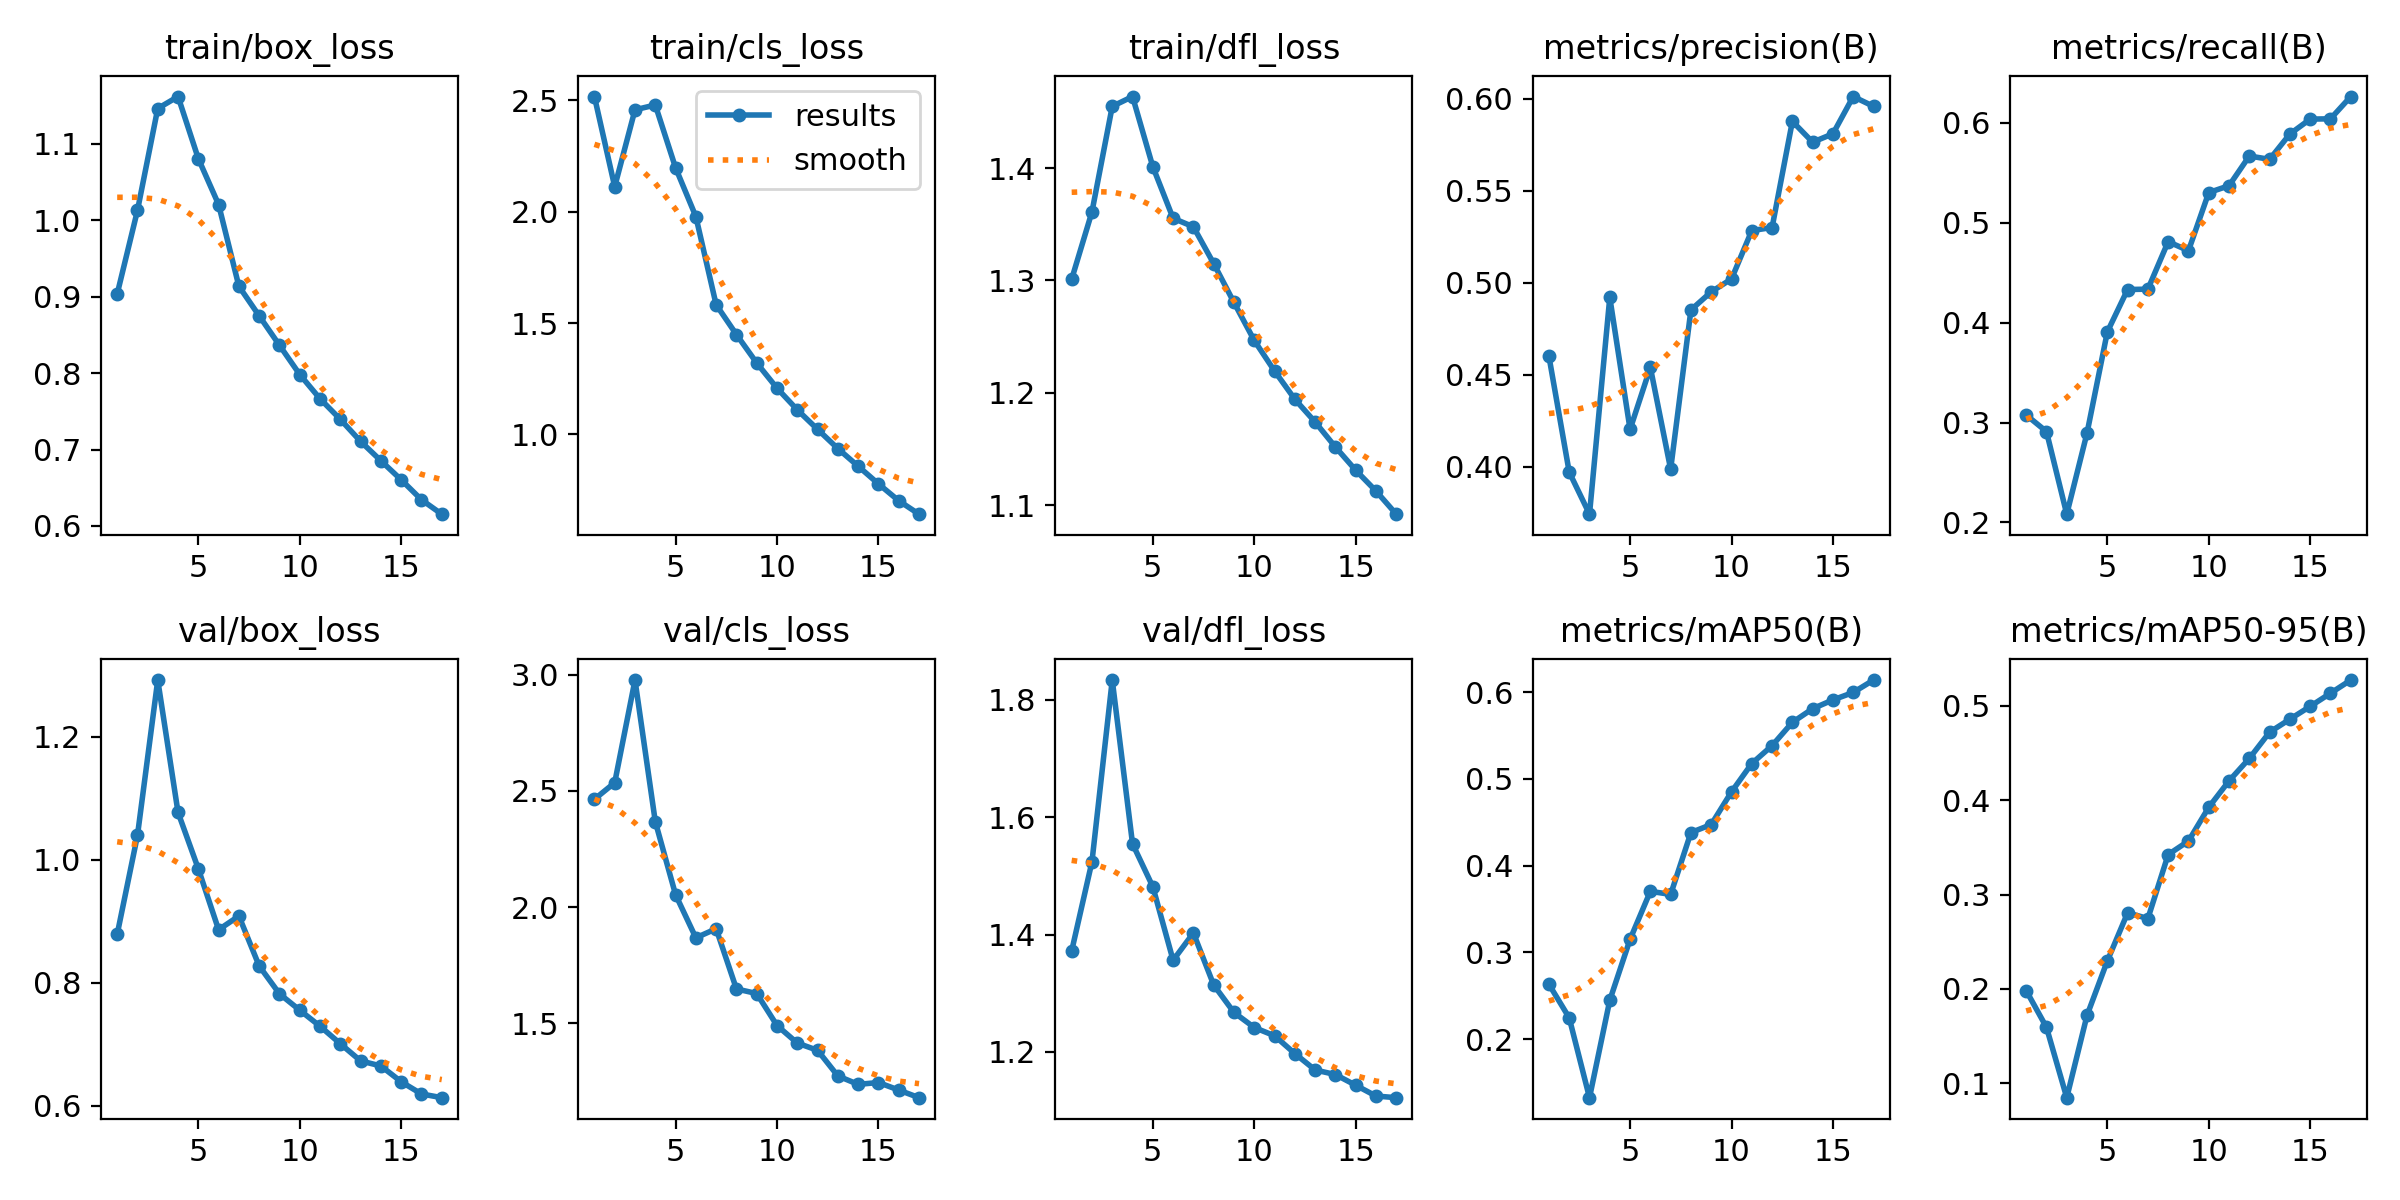

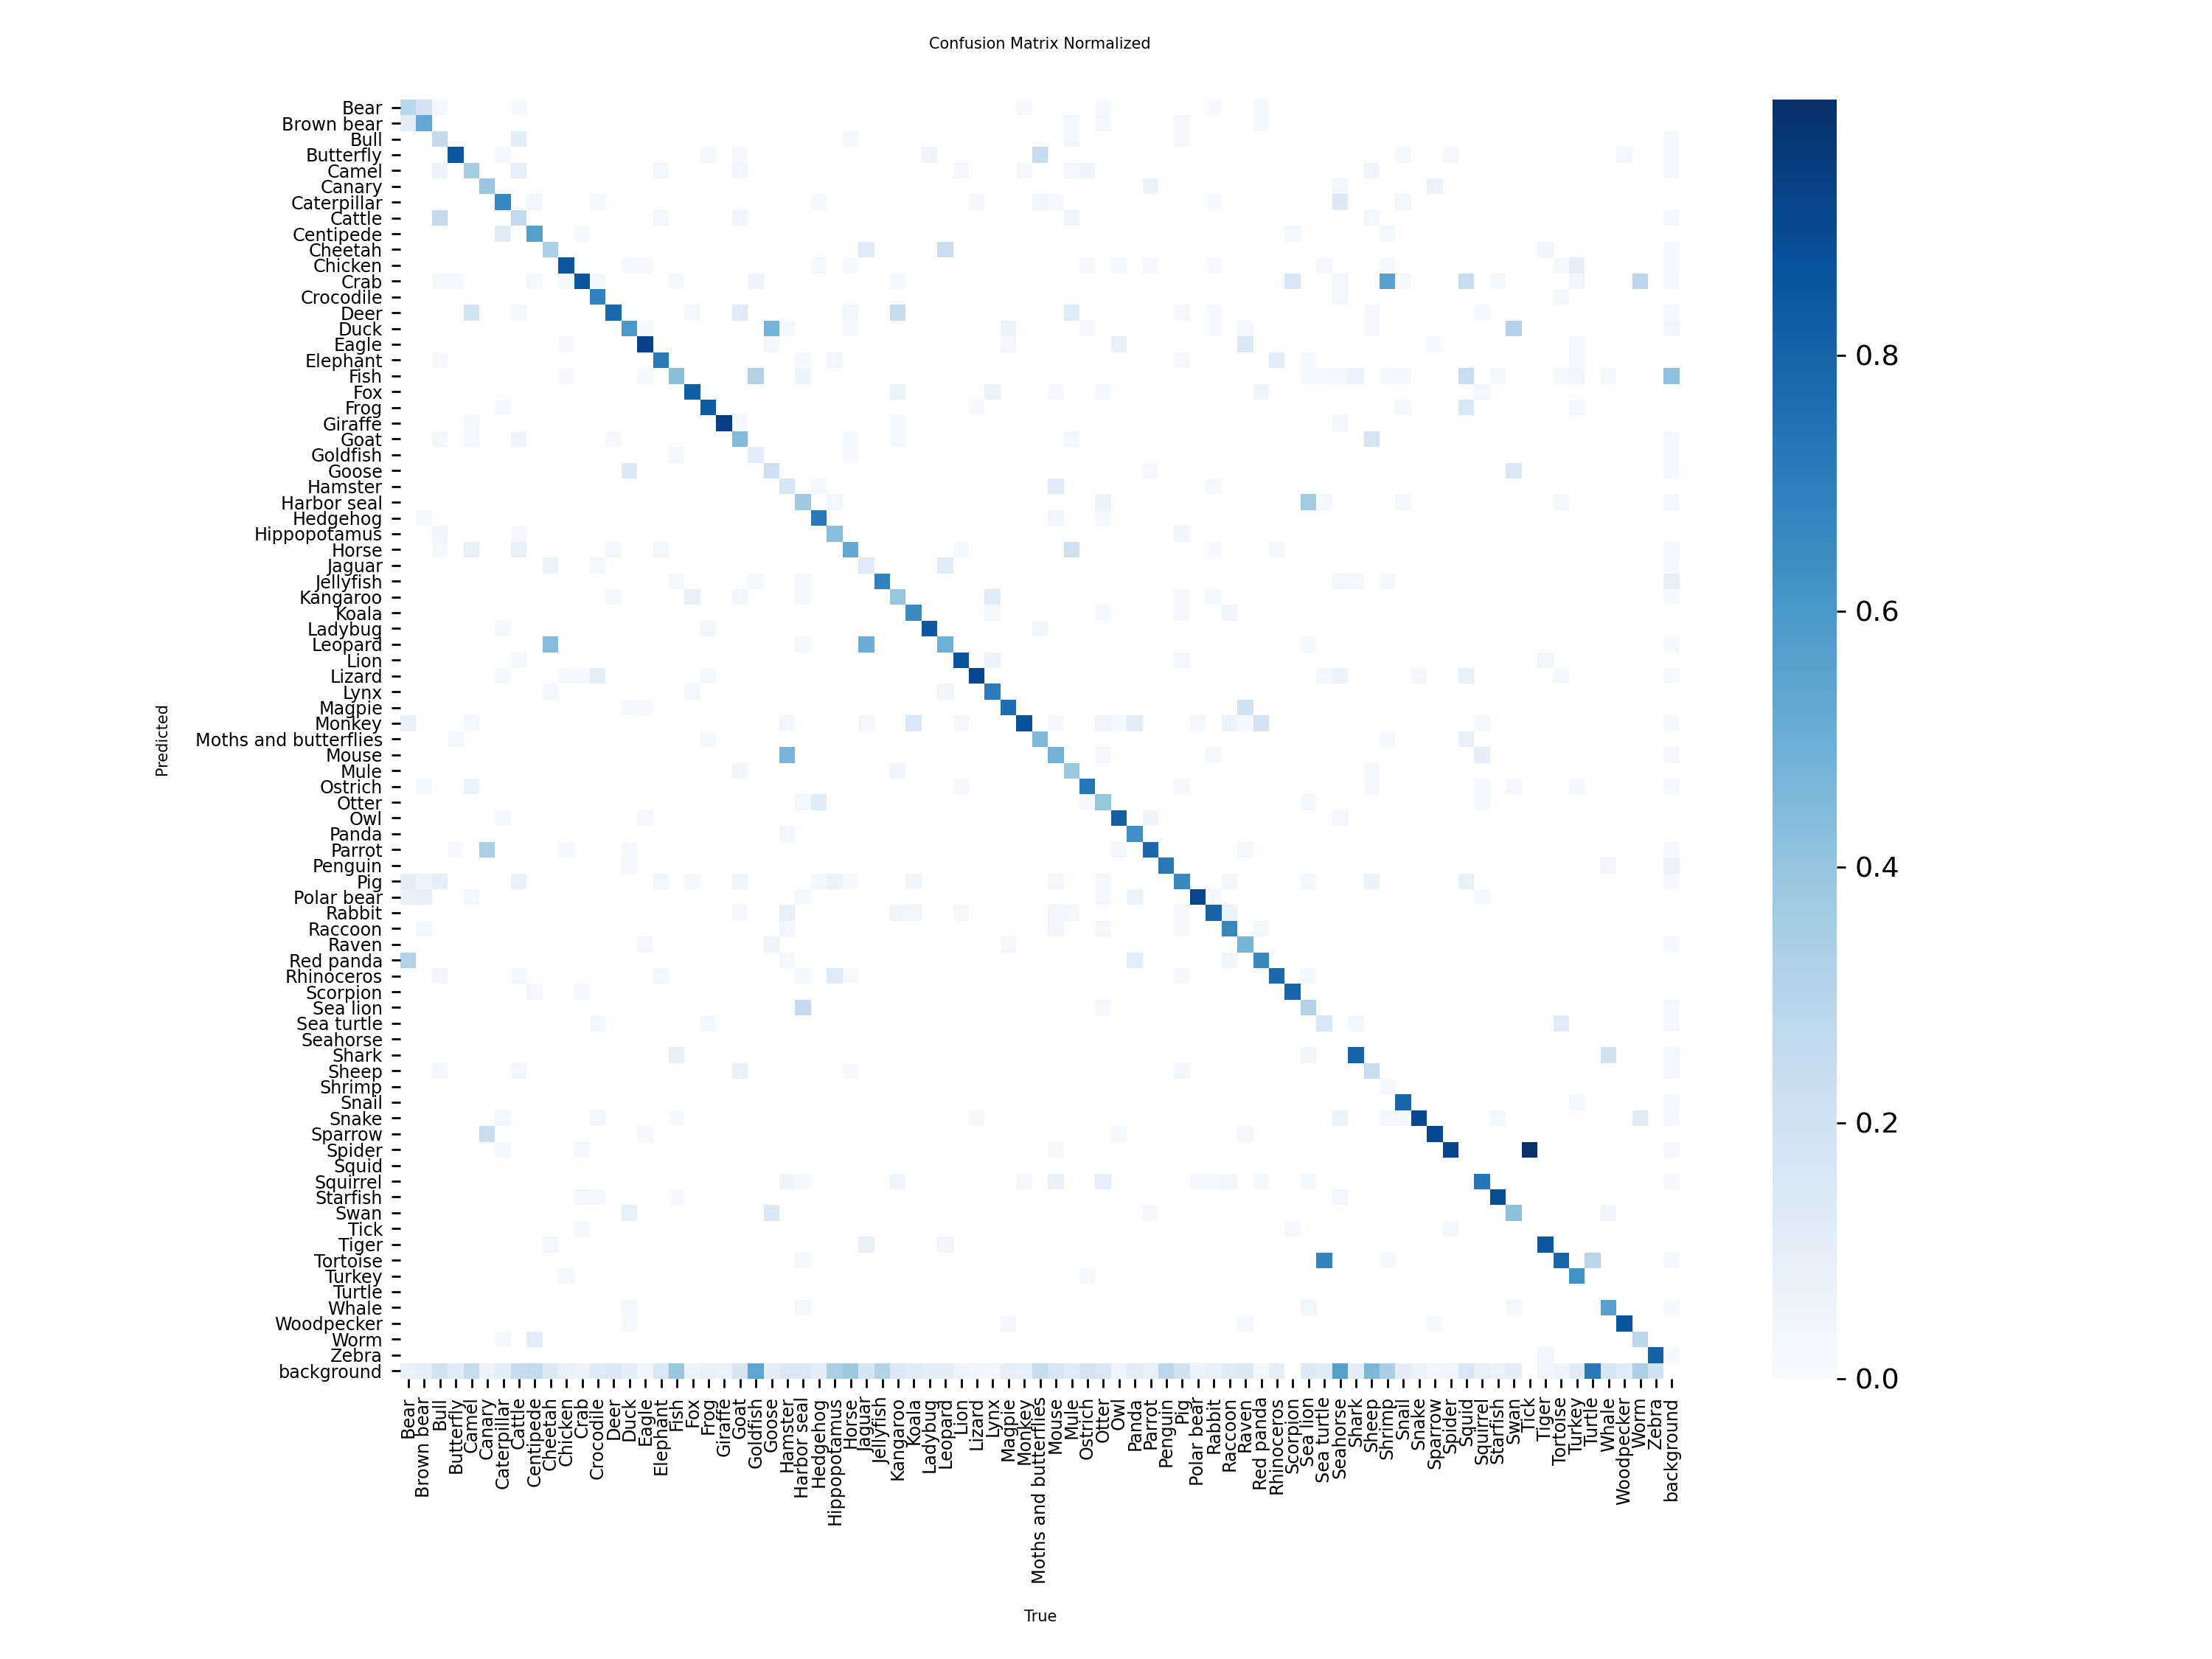

In [7]:
best = '/content/runs/animals/weights/best.pt'
model = YOLO(best)
metrics = model.val(data='/content/yolo_animals/data.yaml')
print(f"mAP@50: {metrics.box.map50:.3f} | mAP@50-95: {metrics.box.map:.3f}")

from IPython.display import Image, display
display(Image('/content/runs/animals/results.png'))
display(Image('/content/runs/animals/confusion_matrix_normalized.png'))

## Run on a video

In [8]:
from google.colab import files
import os, glob, subprocess

up = files.upload()
video_path = '/content/' + list(up.keys())[0]
os.rename(list(up.keys())[0], video_path)


import gc, torch
gc.collect(); torch.cuda.empty_cache()      

model = YOLO('/content/runs/animals/weights/best.pt')
counts, n_frames = {}, 0

for r in model.predict(
        source=video_path, stream=True, conf=0.25, iou=0.5, imgsz=640,
        save=True, project='/content/output', name='video_pred', exist_ok=True,
        line_width=2, verbose=False):
    n_frames += 1
    for k in r.boxes.cls.int().tolist():
        counts[r.names[k]] = counts.get(r.names[k], 0) + 1
    save_dir = r.save_dir
print(f"Processed {n_frames} frames. Detections per class:", counts)
print("Saved to:", save_dir)

Saving animals.mp4 to animals.mp4
Results saved to /content/output/video_pred
Processed 4237 frames. Detections per class: {'Pig': 89, 'Cattle': 167, 'Rhinoceros': 254, 'Zebra': 1195, 'Bull': 35, 'Deer': 351, 'Horse': 958, 'Tiger': 369, 'Hippopotamus': 159, 'Lion': 332, 'Goat': 162, 'Sheep': 52, 'Camel': 299, 'Cheetah': 329, 'Jaguar': 80, 'Leopard': 27, 'Ostrich': 3, 'Elephant': 310, 'Lynx': 200, 'Fox': 198, 'Giraffe': 190, 'Monkey': 379, 'Whale': 6, 'Harbor seal': 1, 'Swan': 14, 'Duck': 26, 'Panda': 129, 'Polar bear': 41, 'Brown bear': 7, 'Shark': 28, 'Fish': 19, 'Sea turtle': 143, 'Jellyfish': 2, 'Bear': 80, 'Mule': 13, 'Chicken': 88, 'Rabbit': 25, 'Hamster': 13, 'Mouse': 37, 'Parrot': 3, 'Kangaroo': 79, 'Penguin': 5}
Saved to: /content/output/video_pred


In [9]:
import glob, base64
from IPython.display import HTML

out = glob.glob('/content/output/video_pred/*.avi') + glob.glob('/content/output/video_pred/*.mp4')
src = out[0]
dst = '/content/output/result.mp4'
!ffmpeg -y -loglevel error -i "{src}" -vcodec libx264 -pix_fmt yuv420p "{dst}"

import os
if os.path.getsize(dst) > 25e6:
    print("Video is large - skipping inline preview. Download it instead:", dst)
else:
    data = base64.b64encode(open(dst, 'rb').read()).decode()
    display(HTML(f'<video width=720 controls><source src="data:video/mp4;base64,{data}" type="video/mp4"></video>'))

Video is large - skipping inline preview. Download it instead: /content/output/result.mp4


## Download the annotated video and the trained weights

In [10]:
files.download('/content/output/result.mp4')
files.download('/content/runs/animals/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>